# Preprocessing Notebook
This is a placeholder notebook for Silver layer.

# Silver Layer – Preprocessing & Feature Analysis

This notebook follows the **complete Silver Layer** data science workflow:

1. **Merging Data & Preparing for Analysis** – Table joins, null handling, churn target creation
2. **Exploratory Data Analysis (EDA) & Visualization** – Distributions, box plots, outliers, correlation heatmap
3. **Hypothesis Testing & Feature Selection** – Statistical tests (Chi-Square, ANOVA, Permutation, Normality, Homoscedasticity, Correlation, VIF)
4. **Creating Churn Categories** – Numeric target encoding (0 = No Churn, 1 = Partial Churn, 2 = Full Churn)
5. **Feature Selection Summary** – Final encoded, proven features for the Gold layer model

---
# 1. Importing the Necessary Modules

In [1]:
import pandas as pd
import numpy as np
import importlib.util
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importing the Necessary File Modules
Using `importlib.util` to add paths dynamically to import the necessary modules from `src/`

In [59]:
# Define paths to all required modules
module_paths = {
    'load_intermediate_data': '../../src/data/load_intermediate_data.py',
    'churn_classification': '../../src/features/churn_classification.py',
    'outlier_detection': '../../src/features/outlier_detection.py',
    'hypothesis_1_chi_square': '../../src/features/hypothesis_1_chi_square.py',
    'hypothesis_2_anova': '../../src/features/hypothesis_2_anova.py',
    'hypothesis_3_permutation_test': '../../src/features/hypothesis_3_permutation_test.py',
    'hypothesis_4_normality': '../../src/features/hypothesis_4_normality.py',
    'hypothesis_5_homoscedasticity': '../../src/features/hypothesis_5_homoscedasticity.py',
    'hypothesis_6_correlation': '../../src/features/hypothesis_6_correlation.py',
    'hypothesis_7_multicollinearity': '../../src/features/hypothesis_7_multicollinearity.py',
    'feature_selection_summary': '../../src/features/feature_selection_summary.py',
    'eda_plots': '../../src/visualization/eda_plots.py',
    'normality_plots': '../../src/visualization/normality_plots.py',
    'merge_data': '../../src/data/merge_data.py',
    'feature_engineering': '../../src/features/feature_engineering.py',
    'hypothesis_plotting':'../../src/features/hypothesis_plotting.py',
}

# Dynamically import all modules
loaded_modules = {}
for name, path in module_paths.items():
    spec = importlib.util.spec_from_file_location(f'src.{name}', path)
    if spec is None:
        raise ImportError(f'Could not load module from {path}')
    module = importlib.util.module_from_spec(spec)
    sys.modules[f'src.{name}'] = module
    spec.loader.exec_module(module)
    loaded_modules[name] = module

# Assign readable aliases
feature_load = loaded_modules['feature_engineering']
hypothesis_module = loaded_modules['hypothesis_plotting']
load_module = loaded_modules['load_intermediate_data']
churn_module = loaded_modules['churn_classification']
merge_module = loaded_modules['merge_data']
outlier_module = loaded_modules['outlier_detection']
hypo_1_module = loaded_modules['hypothesis_1_chi_square']
hypo_2_module = loaded_modules['hypothesis_2_anova']
hypo_3_module = loaded_modules['hypothesis_3_permutation_test']
hypo_4_module = loaded_modules['hypothesis_4_normality']
hypo_5_module = loaded_modules['hypothesis_5_homoscedasticity']
hypo_6_module = loaded_modules['hypothesis_6_correlation']
hypo_7_module = loaded_modules['hypothesis_7_multicollinearity']
summary_module = loaded_modules['feature_selection_summary']
eda_module = loaded_modules['eda_plots']
norm_plot_module = loaded_modules['normality_plots']

print('All modules loaded successfully!')

All modules loaded successfully!


---
# 2. Loading the Intermediate Data
Loading the cleaned datasets from the Bronze layer output (`data/02_intermediate/`)

In [3]:
loaded_data = load_module.LoadIntermediateData()
print('Data loaded successfully using LoadIntermediateData module')

Intermediate data loaded successfully!
Data loaded successfully using LoadIntermediateData module


In [4]:
cleaned_retention = loaded_data.cleaned_retention
cleaned_bob = loaded_data.cleaned_bob

### Display data info and first few rows

In [5]:
print('Cleaned Retention - Data Info:')
print(f'Shape: {cleaned_retention.shape}')
print(f'{cleaned_retention.info()}')
print(f'Null counts:\n{cleaned_retention.isnull().sum()}')
print('First 5 rows:')
display(cleaned_retention.head())

print('\nCleaned BoB - Data Info:')
print(f'Shape: {cleaned_bob.shape}')
print(f'{cleaned_bob.info()}')
print(f'Null counts:\n{cleaned_bob.isnull().sum()}')
print('First 5 rows:')
display(cleaned_bob.head())

Cleaned Retention - Data Info:
Shape: (35286, 4)
<class 'pandas.DataFrame'>
RangeIndex: 35286 entries, 0 to 35285
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   customer_account_number  35286 non-null  str  
 1   case_type                35286 non-null  str  
 2   current_status           35286 non-null  str  
 3   resolution_status        35286 non-null  str  
dtypes: str(4)
memory usage: 1.1 MB
None
Null counts:
customer_account_number    0
case_type                  0
current_status             0
resolution_status          0
dtype: int64
First 5 rows:


,customer_account_number,case_type,current_status,resolution_status
0,UK02-CGBA121453-L,Risk,In Progress,OPEN - In Progress
1,UK02-CGBA027133-L,Risk,In Progress,OPEN - In Progress
2,UK02-SGBA028701-L,Risk,In Progress,OPEN - In Progress
3,UK02-CGBA210070-L,Risk,In Progress,OPEN - In Progress
4,UK02-CGBA212953-L,Risk,In Progress,OPEN - In Progress



Cleaned BoB - Data Info:
Shape: (171665, 14)
<class 'pandas.DataFrame'>
RangeIndex: 171665 entries, 0 to 171664
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   account_number        171665 non-null  str    
 1   branch                171665 non-null  str    
 2   agreement_number      171665 non-null  str    
 3   agreement_start_date  171665 non-null  str    
 4   agreement_end_date    171665 non-null  str    
 5   agreement_type        171665 non-null  str    
 6   system_status         171665 non-null  str    
 7   product_bob           171665 non-null  float64
 8   fee_bob               171665 non-null  float64
 9   total_bob             171665 non-null  float64
 10  is_bob                171665 non-null  str    
 11  unit_amount           169283 non-null  float64
 12  msdyn_product_number  170422 non-null  str    
 13  product_name          170422 non-null  str    
dtypes: float64(4), st

,account_number,branch,agreement_number,agreement_start_date,agreement_end_date,agreement_type,system_status,product_bob,fee_bob,total_bob,is_bob,unit_amount,msdyn_product_number,product_name
0,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,Yes,9812.14,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...
1,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...
2,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...
3,UK02-CGBA124601-L,Lisburn,GBC4000950-Auto waste,2022-06-24,2026-06-23,Scheduled Billing,Active,92242.56,0.0,92242.56,Yes,7686.88,K0000-040259-000,Waste Paint Sludge Collection - 205
4,UK02-CGBA034502-L,Lisburn,GBC3028394-Chemistry,2024-11-04,2025-11-03,Scheduled Billing,Active,83206.92,0.0,83206.92,Yes,6933.91,C0000-000468-001,Delivery of Std Thinners - 205Ltrs (6)


---
# 3. Merging Data and Preparing for Analysis

**Steps performed here:**
- Create churn categories from BoB agreement data (our target variable)
- Aggregate Retention and BoB data at the account level
- Merge all three into a single analysis-ready dataset
- Handle remaining null values via imputation

### 3.1 Merging Retention + BoB 

Joining the three datasets on `account_number` to create a single analysis dataset with appropriate features 

In [6]:
merge_data_module = merge_module.MergeData(cleaned_retention, cleaned_bob)
merge_data_for_analysis = merge_data_module.merge_data()

print('\nMerged Data Info: ')
print('\nNull counts :\n', merge_data_for_analysis.isnull().sum())
print('\nDuplicate Count :\n', merge_data_for_analysis.duplicated().sum())
print('\nData Info :\n', merge_data_for_analysis.info())

Merging retention and BoB data...
Merged dataset shape: (73233, 17)
Columns: ['account_number', 'branch', 'agreement_number', 'agreement_start_date', 'agreement_end_date', 'agreement_type', 'system_status', 'product_bob', 'fee_bob', 'total_bob', 'is_bob', 'unit_amount', 'msdyn_product_number', 'product_name', 'case_type', 'current_status', 'resolution_status']

Merged Data Info: 

Null counts :
 account_number             0
branch                     0
agreement_number           0
agreement_start_date       0
agreement_end_date         0
agreement_type             0
system_status              0
product_bob                0
fee_bob                    0
total_bob                  0
is_bob                     0
unit_amount             1233
msdyn_product_number     283
product_name             283
case_type                  0
current_status             0
resolution_status          0
dtype: int64



Duplicate Count :
 0
<class 'pandas.DataFrame'>
RangeIndex: 73233 entries, 0 to 73232
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_number        73233 non-null  str    
 1   branch                73233 non-null  str    
 2   agreement_number      73233 non-null  str    
 3   agreement_start_date  73233 non-null  str    
 4   agreement_end_date    73233 non-null  str    
 5   agreement_type        73233 non-null  str    
 6   system_status         73233 non-null  str    
 7   product_bob           73233 non-null  float64
 8   fee_bob               73233 non-null  float64
 9   total_bob             73233 non-null  float64
 10  is_bob                73233 non-null  str    
 11  unit_amount           72000 non-null  float64
 12  msdyn_product_number  72950 non-null  str    
 13  product_name          72950 non-null  str    
 14  case_type             73233 non-null  str    
 15  current_

### Saving the final Merged Data 
saving the final merged data for furthur use.

In [7]:
merge_data_for_analysis.to_csv('../../data/03_processed/merged_data.csv', index=False)

### 3.2 Creating Churn Categories

Creating a 3-level churn classification from the BoB data:
- **No Churn (0)**: Customer maintains all active agreements
- **Partial Churn (1)**: Customer loses some agreements but keeps others (agreement-level churn)
- **Full Churn (2)**: Customer loses ALL agreements (customer-level churn)

In [8]:
churn_classification = churn_module.ChurnClassification(merge_data_for_analysis)
churn_classified_df = churn_classification.classify_churn()

print('\Churn Categorised Data Info: ')
print('\nShape of Churn Categorised Data :\n', churn_classified_df.shape)
print('\nNull counts :\n', churn_classified_df.isnull().sum())
print('\nDuplicate Count :\n', churn_classified_df.duplicated().sum())
print('\nData Info :\n', churn_classified_df.info())

Performing churn classification...
Churn dataset shape: (5628, 5)
Columns: ['account_number', 'total_agreements', 'active_agreements', 'lost_agreements', 'target']
\Churn Categorised Data Info: 

Shape of Churn Categorised Data :
 (5628, 5)

Null counts :
 account_number       0
total_agreements     0
active_agreements    0
lost_agreements      0
target               0
dtype: int64

Duplicate Count :
 0
<class 'pandas.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   account_number     5628 non-null   str  
 1   total_agreements   5628 non-null   int64
 2   active_agreements  5628 non-null   int64
 3   lost_agreements    5628 non-null   int64
 4   target             5628 non-null   str  
dtypes: int64(3), str(2)
memory usage: 220.0 KB

Data Info :
 None


In [9]:
display(churn_classified_df['target'].unique())

<StringArray>
['no_churn', 'full_churn', 'partial_churn']
Length: 3, dtype: str

In [10]:
# Calculating the percentage distribution of the churn categorised
churn_distribution = churn_classified_df['target'].value_counts(normalize=True) * 100
print('Churn Percentage Distribution:')
display(churn_distribution.round(2).astype(str) + '%')


Churn Percentage Distribution:


target
no_churn         66.68%
full_churn       33.28%
partial_churn     0.04%
Name: proportion, dtype: str

In [11]:
churn_classified_df.to_csv('../../data/03_processed/churn_categorised.csv', index= False)

---
# 4. Hypothesis Definition

**Target Variable**: Churn (0 = No, 1 = Partial, 2 = Full)

**Hypothesis 1 (Chi-Square)**:
*H0*: Categorical features are independent of the Churn category.
*H1*: Categorical features are dependent on the Churn category.

**Hypothesis 2 (ANOVA)**:
*H0*: The means of continuous features are equal across all churn categories.
*H1*: At least one churn category has a different mean for the continuous feature.

**Hypothesis 3 (Spearman Correlation)**:
*H0*: No monotonic correlation exists between continuous features and the ordinal churn target.
*H1*: A significant monotone correlation exists.

---
# 5. Hypothesis Testing (with Distributions)

Running formal statistical tests (alpha = 0.05). For each test, we also plot the underlying distribution.

In [71]:
hypo_module = hypothesis_module.HypothesisPlotting()

In [60]:
# Ensure we have the target properly mapped
churn_map = {'no_churn': 0, 'partial_churn': 1, 'full_churn': 2}
if 'target' in churn_classified_df.columns:
    churn_classified_df['churn_ordinal'] = churn_classified_df['target'].map(churn_map)

# Create the final analysis DF for this section by merging categories back
analysis_df = pd.merge(merge_data_for_analysis, churn_classified_df, on='account_number', how='left')
analysis_df.rename(columns={'target': 'churn_category'}, inplace=True)

continuous_features = ['total_agreements', 'active_agreements', 'lost_agreements', 'avg_fee_bob', 'total_revenue_bob']
continuous_features = [f for f in continuous_features if f in analysis_df.columns]

### 5.1 Hypothesis 1: Chi-Square Test of Independence

This test formally evaluates whether the categorical features are independent of the customer's churn outcome. We calculate the chi-square statistic and report the p-value. A p-value < 0.05 leads us to reject the null hypothesis, indicating a significant dependency.

In [61]:
# Run Hypothesis 1: Chi-Square Test
hypo_1_tester = hypo_1_module.Hypothesis1ChiSquare(analysis_df, target_column='churn_category')
res_1 = hypo_1_tester.run_test()
display(pd.DataFrame(res_1))

Hypothesis 1: Categorical Independence (Chi-Square Test)
Null: Feature is independent of churn category
Alternative: Feature is dependent on churn category


""


### 5.2 Hypothesis 2: ANOVA (Analysis of Variance)

ANOVA helps us determine if the means of continuous numerical features differ significantly across multiple groups (No Churn, Partial Churn, Full Churn). When a feature proves to be statistically significant, we subsequently render its stacked density-histogram to visually inspect the difference in its distribution.

Hypothesis 2: Difference in Means (ANOVA)
Null: No significant difference in feature means across churn categories
Alternative: Significant difference exists


,Feature,Test,Statistic,P-Value,Significant
0,total_agreements,ANOVA,4102.34,0.0,True
1,active_agreements,ANOVA,4095.72,0.0,True
2,lost_agreements,ANOVA,5116.66,0.0,True


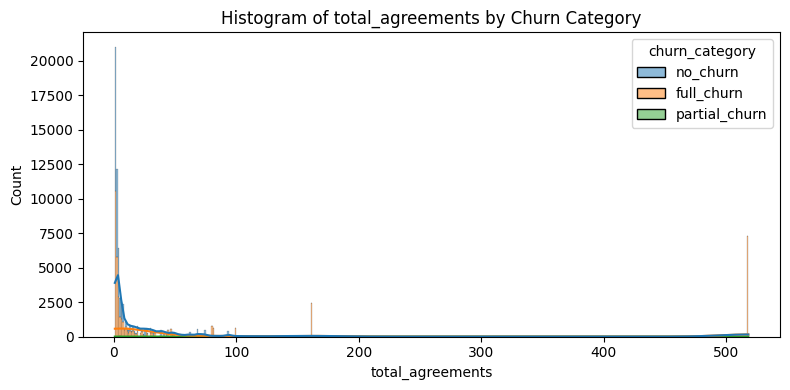

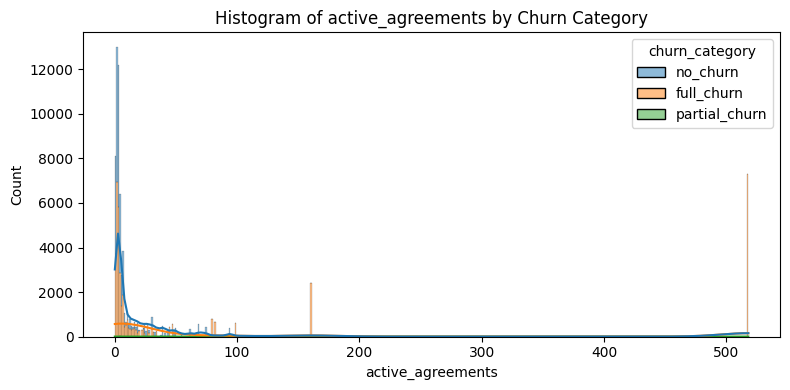

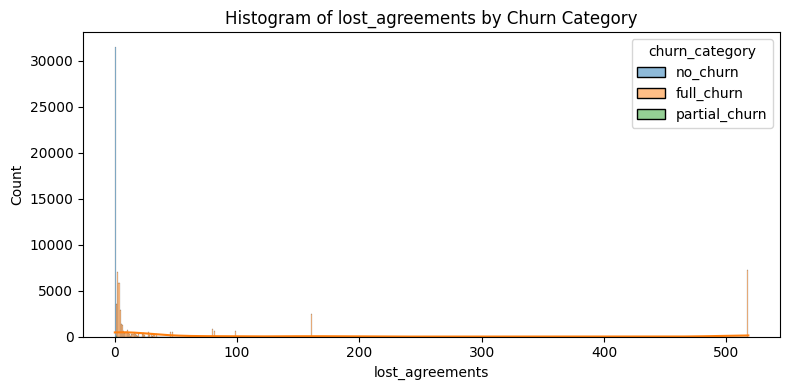

In [72]:
# Run Hypothesis 2: ANOVA
hypo_2_tester = hypo_2_module.Hypothesis2ANOVA(analysis_df, target_column='churn_ordinal')
res_2 = hypo_2_tester.run_test()
display(pd.DataFrame(res_2))

for r in res_2:
    if r['Significant']:
        hypo_module.plot_feature_histogram(analysis_df, r['Feature'])


### 5.3 Hypothesis 3: Spearman Correlation

Because our target variable represents an ordinal sequence of severity (`0=No Churn`, `1=Partial Churn`, `2=Full Churn`), we utilize Spearman's rank-order correlation. This non-parametric test will identify purely monotonic relationships between the continuous features and churn risk.

Hypothesis 6: Correlation Analysis
Null: No correlation between feature and churn
Alternative: Significant correlation exists


""



Generating Correlation Heatmap...


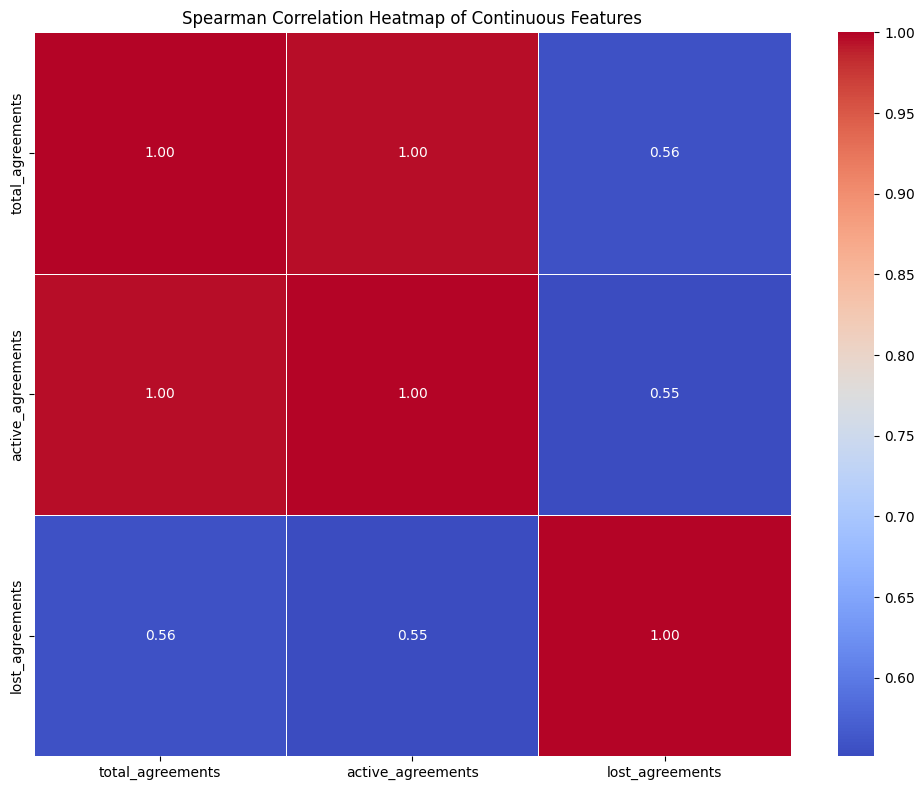

,total_agreements,active_agreements,lost_agreements
total_agreements,1.000000,0.995419,0.556751
active_agreements,0.995419,1.000000,0.551462
lost_agreements,0.556751,0.551462,1.000000


In [73]:
# Run Hypothesis 6: Correlation (Spearman)
hypo_6_tester = hypo_6_module.Hypothesis6Correlation(analysis_df, target_column='churn_category')
res_6 = hypo_6_tester.run_test()
display(pd.DataFrame(res_6))

# Plot the specified correlation metric (heatmap) inline
print('\nGenerating Correlation Heatmap...')
hypo_module.plot_correlation_heatmap(analysis_df, continuous_features)


---
# 6. Exploratory Data Analysis (EDA)

This section visualizes the boundaries, outliers, and density distributions of our numeric features against the churn target to draw insights prior to modeling.

### Box Plots
Box plots explicitly identify numeric outliers and visualize the interquartile range (IQR) of features relative to severity layers defined by No Churn, Partial Churn, and Full Churn categories.

### Density Curves
Density KDE (Kernel Density Estimation) curves overlay the probability distributions on top of each other. This is crucial for interpreting overlap; if the churn and no-churn curves are distinctly separated, the feature exhibits high predictive power.

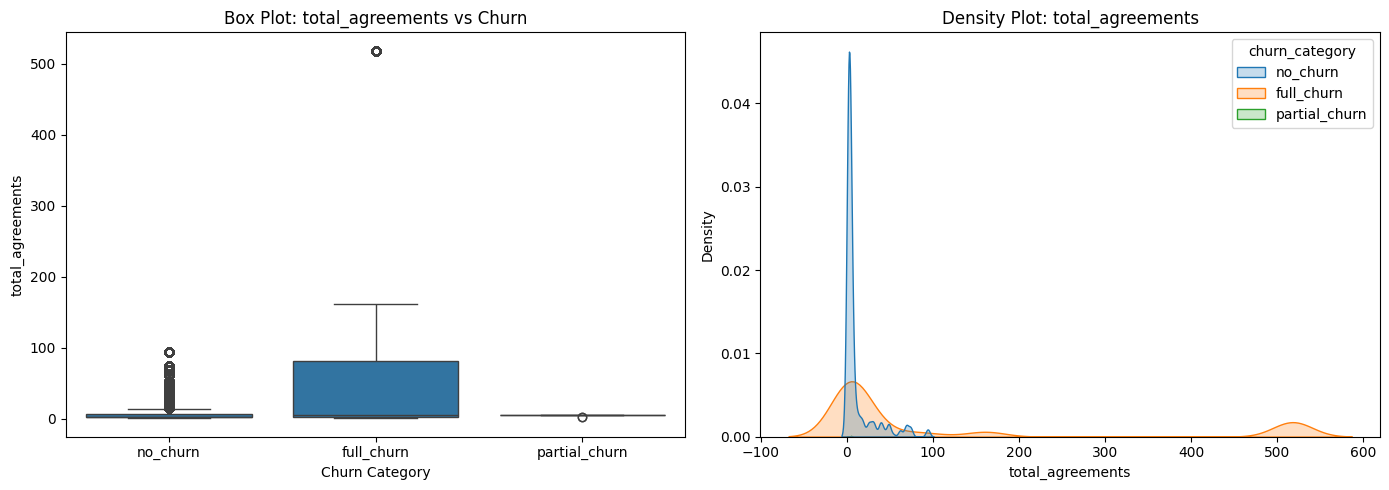

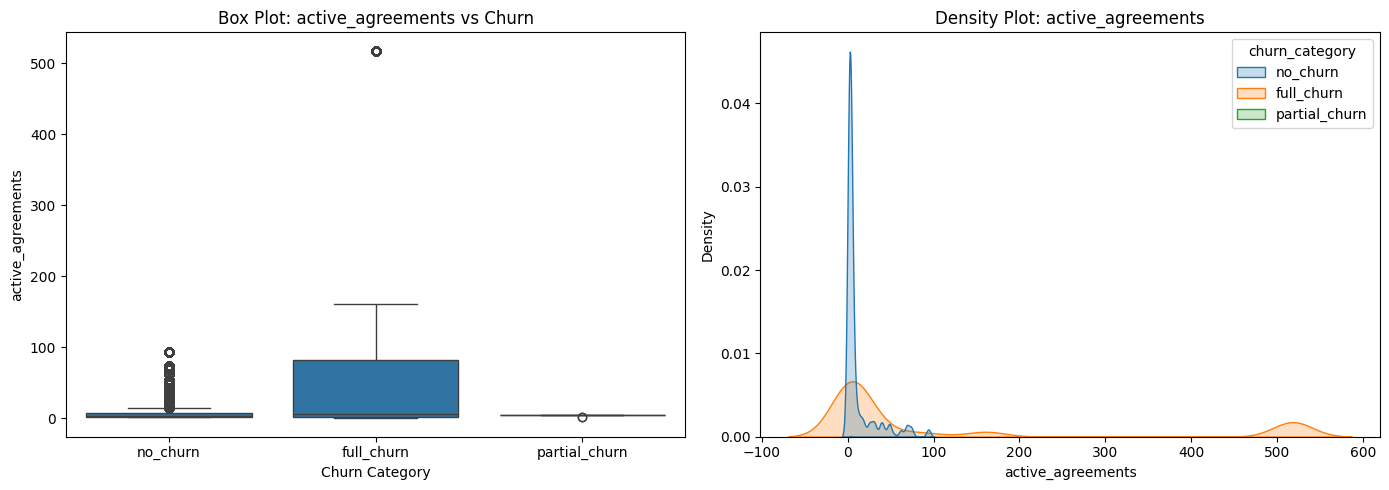

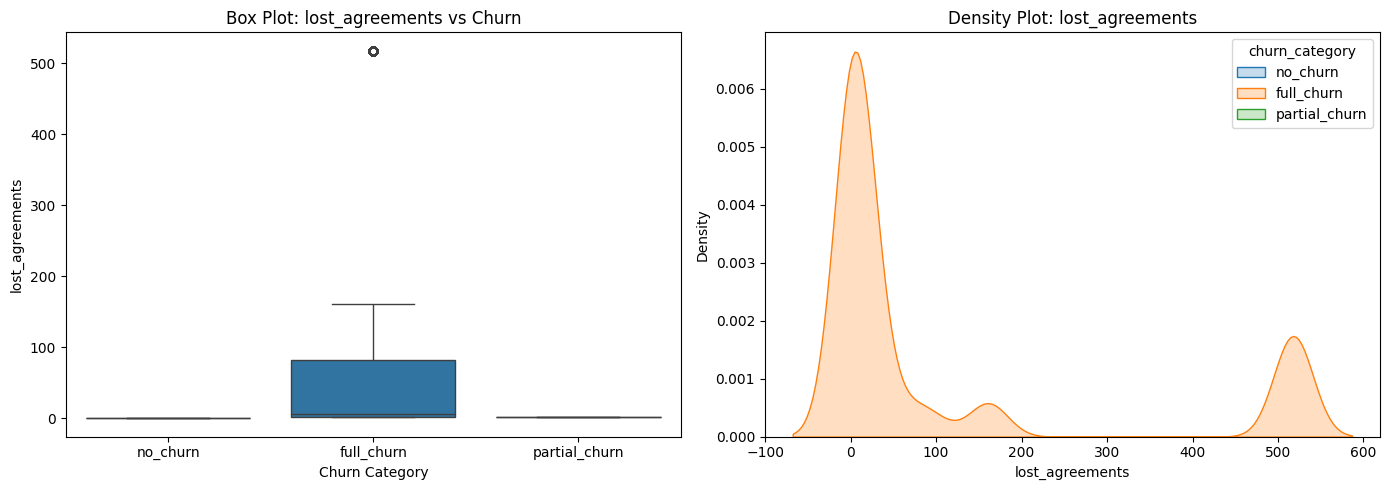

In [74]:
for feature in continuous_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box Plot
    sns.boxplot(data=analysis_df, x='churn_category', y=feature, ax=axes[0])
    axes[0].set_title(f'Box Plot: {feature} vs Churn')
    axes[0].set_xlabel('Churn Category')
    axes[0].set_ylabel(feature)

    # Density Plot
    sns.kdeplot(data=analysis_df, x=feature, hue='churn_category', fill=True, ax=axes[1])
    axes[1].set_title(f'Density Plot: {feature}')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Density')

    plt.tight_layout()
    plt.show()

---
# 7. Feature Engineering

During this phase, we transform raw variables into robust features tailored specifically for complex modeling. This logic is decoupled into a reusable pipeline loaded dynamically from `src/features/feature_engineering.py`.

**Pipeline Transformations**:
1. **Missing Data Imputation**: Categorical Unknowns (e.g., `product_name`) are isolated cleanly, while numerics (e.g., `unit_amount`) are imputed using stable median estimates.
2. **Feature Synthesis**: High-level representations are mathematically integrated, like `agreement_duration_days` from distinct timestamps, and the continuous `active_ratio`.
3. **Standardized Scaling**: Core numeric variables are processed through `StandardScaler` to uniform Z-score boundaries strictly preventing unbounded variances from skewing distance-based or neural models.

In [75]:
fe_pipeline = feature_load.FeatureEngineering(analysis_df)
final_analysis_df = fe_pipeline.engineer_features()
display(final_analysis_df.head())

Starting feature engineering process...
Handling missing values...
Creating date-based features...
Creating agreement ratio feature...
Scaling continuous features...
Feature engineering complete. New shape: (73233, 29)


,account_number,branch,agreement_number,agreement_start_date,agreement_end_date,agreement_type,system_status,product_bob,fee_bob,total_bob,...,lost_agreements,churn_category,churn_ordinal,agreement_duration_days,active_ratio,total_agreements_scaled,active_agreements_scaled,lost_agreements_scaled,agreement_duration_days_scaled,active_ratio_scaled
0,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,...,0,no_churn,0,364,1.0,0.175182,0.175417,-0.402916,-1.489101,0.050748
1,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,...,0,no_churn,0,364,1.0,0.175182,0.175417,-0.402916,-1.489101,0.050748
2,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,...,0,no_churn,0,1095,1.0,0.175182,0.175417,-0.402916,-0.616286,0.050748
3,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,...,0,no_churn,0,1095,1.0,0.175182,0.175417,-0.402916,-0.616286,0.050748
4,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,...,0,no_churn,0,1095,1.0,0.175182,0.175417,-0.402916,-0.616286,0.050748


## Saving the Feature Engineering Dataset

In [76]:
final_analysis_df.to_csv('../../data/03_processed/feature_engineered_data.csv', index= False)